# Arctic Watch: starter notebook

Practice challenge 01 of Canada's Defence Tech Hackathon (Edmonton and online, Nov 14–15 2026).

This notebook walks through the data, builds a simple baseline for both tasks, scores it on a validation split and writes a valid submission. It runs top to bottom in about a minute on a laptop and only needs pandas, numpy, matplotlib and scikit-learn. Run it from this folder.

All data here is synthetic and fictional. Ship IDs (MMSIs) start with 999, the flags carry no signal, and the areas of interest are illustrative. The closed fishing area is made up for this exercise.

## 1. The challenge in plain language

Most larger ships carry an AIS transponder (Automatic Identification System) that broadcasts the ship's identity, position, speed and course every few seconds to minutes. Shore stations and satellites pick these messages up, which is how ship-tracking websites work. A SAR satellite (synthetic aperture radar) takes radar images of the sea that work at night and through cloud, and a ship shows up in them as a bright spot whether or not it is broadcasting. Icebergs and patches of rough water can show up as bright spots too. A *dark vessel* is a ship the radar sees but that is not broadcasting AIS at that moment, because its transponder is off, broken or missing. Matching radar spots to AIS tracks, and looking for odd behaviour in the tracks themselves, is how analysts decide which ships deserve a closer look.

The scenario covers 14 days in the Canadian Arctic, starting 2025-09-01 00:00 UTC. Labels are given for the first 9 days. Your predictions are for the hidden **test window: 2025-09-10 00:00 UTC to 2025-09-15 00:00 UTC**.

**Task 1A: classify SAR detections.** Label every SAR detection in the test window as `ais_vessel` (a ship broadcasting AIS), `dark_vessel` (a ship that is not broadcasting) or `not_vessel` (an iceberg or sea clutter). Submit `submissions/sar_labels.csv` with columns `detection_id,label`. Score: macro F1 over the three classes (the average of the three per-class F1 scores, so the rare `dark_vessel` class counts as much as the others). Detections you leave out count as wrong.

**Task 1B: find behaviour events.** Submit `submissions/behaviour_events.csv` with columns `event_type,mmsi,start,end`, times in ISO 8601 UTC (for example `2025-09-11T14:30:00Z`).

| event_type | what it means |
|---|---|
| `ais_gap_intentional` | a ship switches its AIS off for a long stretch while at sea |
| `protected_area_entry` | a ship goes into the closed fishing area `AOI_DAVIS_CLOSED` |
| `loitering` | a ship lingers slowly in one small spot of a sensitive area for many hours |
| `rendezvous` | two ships stop side by side at sea, far from port |
| `position_spoofing` | a ship broadcasts a position that is not where it really is |
| `identity_change` | a ship starts broadcasting a different MMSI and name partway through a trip |
| `mmsi_clone` | one ship broadcasts another ship's MMSI, so that MMSI shows up in two places at once |

When an event involves two ships, put both MMSIs in the `mmsi` column separated by `;`. If the other ship has no AIS, write `DARK`, for example `999123456;DARK`. A predicted event counts as a hit when it has the same type, shares at least one MMSI with a true event (`DARK` does not count) and overlaps it in time, with 2 hours of slack on each side. Each true event can be matched only once. Score: micro F1 over all events. An event belongs to the window that contains its midpoint.

`score.py` in this folder implements both metrics exactly as described.

## 2. Load and inspect the data

| file | what is in it |
|---|---|
| `ais_positions.csv` | AIS reports: time, MMSI, position, speed over ground (`sog`, knots), course (`cog`, 360 = not available), heading (511 = not available), navigation status (0 = under way, 1 = at anchor, 5 = moored, 7 = fishing, 15 = not defined) and whether a shore station (`terrestrial`) or a satellite picked it up |
| `vessels.csv` | what each transponder says about its ship: name, call sign, type, flag, size, declared destination |
| `sar_detections.csv` | bright spots found in SAR images: time, position, estimated length, heading (only when a wake was visible) and the detector's confidence |
| `sar_passes.geojson` | the footprint of each satellite image |
| `areas_of_interest.geojson` | five areas of interest, all simple latitude/longitude rectangles |
| `ais_receivers.csv` | shore AIS stations (about 70 km range); everywhere else relies on satellites |
| `labels_train/` | answers for the first 9 days: `sar_detection_labels.csv` (with the true class and MMSI) and `behaviour_events.csv` |

In [1]:
import os
import json
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

plt.rcParams.update({'figure.dpi': 80, 'savefig.dpi': 80, 'font.size': 9})
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

T0 = pd.Timestamp('2025-09-01T00:00:00Z')      # scenario start
SPLIT = pd.Timestamp('2025-09-10T00:00:00Z')   # labels exist before this; the test window starts here


def hours(t):
    # hours since the scenario start: easier to compute with than timestamps
    return (pd.to_datetime(t, utc=True) - T0).dt.total_seconds() / 3600


def iso(h):
    return (T0 + pd.to_timedelta(np.asarray(h, dtype=float), unit='h')).strftime('%Y-%m-%dT%H:%M:%SZ')


def km(lat1, lon1, lat2, lon2):
    # great-circle distance in km, works on numbers and numpy arrays
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(np.asarray(lon2) - np.asarray(lon1)) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


ais = pd.read_csv('ais_positions.csv', dtype={'mmsi': str})
vessels = pd.read_csv('vessels.csv', dtype={'mmsi': str})
det = pd.read_csv('sar_detections.csv')
receivers = pd.read_csv('ais_receivers.csv')
sar_labels = pd.read_csv('labels_train/sar_detection_labels.csv', dtype={'truth_mmsi': str})
event_labels = pd.read_csv('labels_train/behaviour_events.csv', dtype={'mmsi': str})
with open('areas_of_interest.geojson') as f:
    aois = {ft['properties']['aoi_id']: np.array(ft['geometry']['coordinates'][0]) for ft in json.load(f)['features']}

ais['time'] = pd.to_datetime(ais['timestamp'], utc=True)
ais['t_h'] = hours(ais['time'])
ais = ais.sort_values(['mmsi', 't_h']).reset_index(drop=True)
det['time'] = pd.to_datetime(det['timestamp'], utc=True)
det['t_h'] = hours(det['time'])

print(f"AIS: {len(ais):,} reports from {ais.mmsi.nunique()} transponders, {ais.time.min():%Y-%m-%d} to {ais.time.max():%Y-%m-%d}")
print(f"SAR: {len(det):,} detections in {det.pass_id.nunique()} satellite images, {(det.time < SPLIT).sum()} before the test window and {(det.time >= SPLIT).sum()} in it")
print(f"Labels: {len(sar_labels)} SAR detections and {len(event_labels)} behaviour events (first 9 days)")
ais.head()

AIS: 94,065 reports from 112 transponders, 2025-09-01 to 2025-09-14
SAR: 1,270 detections in 89 satellite images, 652 before the test window and 618 in it
Labels: 652 SAR detections and 15 behaviour events (first 9 days)


,timestamp,mmsi,lat,lon,sog,cog,heading,nav_status,source,time,t_h
0,2025-09-01T00:02:30Z,999026992,63.88898,-58.90597,11.5,347.2,349.0,0,satellite,2025-09-01 00:02:30+00:00,0.041667
1,2025-09-01T00:13:31Z,999026992,63.92081,-58.92220,11.6,348.3,348.0,0,satellite,2025-09-01 00:13:31+00:00,0.225278
2,2025-09-01T00:26:36Z,999026992,63.95860,-58.94145,11.4,348.1,341.0,0,satellite,2025-09-01 00:26:36+00:00,0.443333
3,2025-09-01T00:29:37Z,999026992,63.96740,-58.94566,11.5,345.9,341.0,0,satellite,2025-09-01 00:29:37+00:00,0.493611
4,2025-09-01T01:12:32Z,999026992,64.09242,-59.00919,11.3,348.2,348.0,0,satellite,2025-09-01 01:12:32+00:00,1.208889


In [2]:
print('AIS reports by source:', ais.source.value_counts().to_dict())
print('Ship types:', vessels.ais_type.value_counts().to_dict())
det.head()

AIS reports by source: {'terrestrial': 68380, 'satellite': 25685}
Ship types: {'Fishing': 37, 'Cargo': 31, 'Tanker': 10, 'Pleasure craft': 8, 'Tug': 8, 'Other (research)': 6, 'Passenger': 6, 'Law enforcement': 5, 'Not available': 1}


,detection_id,pass_id,timestamp,lat,lon,length_m,heading_deg,confidence,time,t_h
0,D00001,P001,2025-09-01T00:22:00Z,68.21438,-99.27998,57.0,NaN,0.17,2025-09-01 00:22:00+00:00,0.366667
1,D00002,P001,2025-09-01T00:22:00Z,72.96929,-103.24029,30.0,NaN,0.43,2025-09-01 00:22:00+00:00,0.366667
2,D00003,P001,2025-09-01T00:22:00Z,68.25023,-100.49899,33.0,NaN,0.44,2025-09-01 00:22:00+00:00,0.366667
3,D00004,P001,2025-09-01T00:22:00Z,69.06920,-104.98573,123.0,NaN,0.92,2025-09-01 00:22:00+00:00,0.366667
4,D00005,P001,2025-09-01T00:22:00Z,70.97535,-97.23158,44.0,NaN,0.13,2025-09-01 00:22:00+00:00,0.366667


In [3]:
print('SAR labels (first 9 days):', sar_labels.label.value_counts().to_dict())
print('What the not_vessel spots really are:', sar_labels[sar_labels.label == 'not_vessel'].truth_class.value_counts().to_dict())
event_labels

SAR labels (first 9 days): {'ais_vessel': 332, 'not_vessel': 293, 'dark_vessel': 27}
What the not_vessel spots really are: {'iceberg': 218, 'clutter': 75}


,event_id,event_type,mmsi,start,end,note
0,E003,ais_gap_intentional,999097698,2025-09-01T11:23:00Z,2025-09-01T21:35:00Z,AIS off around a meeting with a dark vessel
1,E004,rendezvous,999097698;DARK,2025-09-01T12:49:00Z,2025-09-01T19:14:00Z,"two vessels stationary together at sea, far fr..."
2,E005,rendezvous,999700059;999896180,2025-09-01T18:55:00Z,2025-09-02T01:19:00Z,"two vessels stationary together at sea, far fr..."
3,E006,ais_gap_intentional,999507638,2025-09-02T04:34:00Z,2025-09-04T15:28:00Z,AIS off while fishing inside the closed area
4,E007,protected_area_entry,999507638,2025-09-02T05:14:00Z,2025-09-04T15:11:00Z,entered illustrative closed area AOI_DAVIS_CLOSED
5,E008,identity_change,999608808;999053472,2025-09-02T12:35:00Z,2025-09-02T13:35:00Z,same hull starts broadcasting a different MMSI...
6,E014,loitering,999345681,2025-09-06T12:43:00Z,2025-09-07T06:54:00Z,loitering inside AOI_LANCASTER with AIS on
7,E015,position_spoofing,999357945,2025-09-06T20:01:00Z,2025-09-06T23:34:00Z,broadcast positions do not match true position...
8,E017,ais_gap_intentional,999904494,2025-09-07T15:08:00Z,2025-09-09T07:31:00Z,AIS off while fishing inside the closed area
9,E018,protected_area_entry,999904494,2025-09-07T15:32:00Z,2025-09-09T06:47:00Z,entered illustrative closed area AOI_DAVIS_CLOSED


## 3. A first look

Grey dots are AIS reports, so the busier lines are the shipping routes. Coloured marks are SAR detections from the labelled days. The boxes are the areas of interest and the triangles are the shore AIS stations.

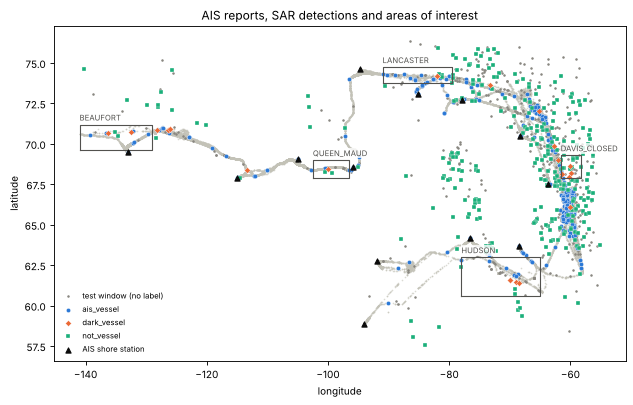

In [4]:
labelled = det.merge(sar_labels[['detection_id', 'label']], on='detection_id', how='left')
style = {'ais_vessel': ('#2a78d6', 'o', 3), 'dark_vessel': ('#eb6834', 'D', 4), 'not_vessel': ('#1baf7a', 's', 3)}

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ais.lon, ais.lat, '.', ms=0.6, color='#c3c2b7', zorder=1)
test = labelled[labelled.label.isna()]
ax.scatter(test.lon, test.lat, s=6, color='#898781', marker='.', label='test window (no label)', zorder=2)
for name, (color, marker, z) in style.items():
    d = labelled[labelled.label == name]
    ax.scatter(d.lon, d.lat, s=14, color=color, marker=marker, edgecolor='white', linewidth=0.3, label=name, zorder=z)
for aoi_id, xy in aois.items():
    ax.plot(xy[:, 0], xy[:, 1], color='#52514e', lw=1, zorder=4)
    ax.text(xy[:, 0].min(), xy[:, 1].max() + 0.25, aoi_id.replace('AOI_', ''), fontsize=7, color='#52514e',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.5), zorder=6)
ax.scatter(receivers.lon, receivers.lat, marker='^', s=22, color='#0b0b0b', label='AIS shore station', zorder=5)
ax.set_aspect(1 / np.cos(np.radians(68)))
ax.set(xlabel='longitude', ylabel='latitude', title='AIS reports, SAR detections and areas of interest')
ax.legend(fontsize=7, loc='lower left', frameon=False)
plt.tight_layout()
plt.show()

Two things the baseline below relies on. Left: ships tend to be longer and get higher detector confidence than icebergs and sea clutter, but the groups overlap, so size and confidence alone are not enough. Right: far from shore stations, AIS reports arrive through satellites every half hour or so, and gaps of a few hours are normal. Much longer gaps are rare.

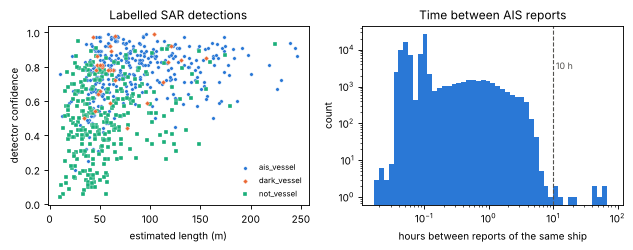

Gaps longer than 10 hours: 10 out of 93,953


In [5]:
gaps_h = ais.groupby('mmsi').t_h.diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2))
for name, (color, marker, z) in style.items():
    d = labelled[labelled.label == name]
    ax1.scatter(d.length_m, d.confidence, s=10, color=color, marker=marker, edgecolor='white', linewidth=0.3, label=name, zorder=z)
ax1.set(xlabel='estimated length (m)', ylabel='detector confidence', title='Labelled SAR detections')
ax1.legend(fontsize=7, frameon=False)

bins = np.logspace(np.log10(1 / 60), np.log10(80), 50)
ax2.hist(gaps_h, bins=bins, color='#2a78d6')
ax2.axvline(10, color='#52514e', lw=1, ls='--')
ax2.text(11, 3000, '10 h', fontsize=8, color='#52514e')
ax2.set(xscale='log', yscale='log', xlabel='hours between reports of the same ship', ylabel='count', title='Time between AIS reports')
plt.tight_layout()
plt.show()
print(f"Gaps longer than 10 hours: {(gaps_h > 10).sum()} out of {len(gaps_h):,}")

## 4. A validation split

We keep the last two labelled days (Sep 8 and 9) aside to check the baseline and train on Sep 1 to 7. This mimics the real setup, where you predict days you have no labels for. The validation labels are written to temporary files in the same format as the hidden test labels, so `score.py` can read them. Behaviour events go to the window that contains their midpoint, the same rule used for the test window.

In [6]:
VAL_START = SPLIT - pd.Timedelta(days=2)

lab_det = det.merge(sar_labels, on='detection_id')
is_val = lab_det.time >= VAL_START
train_det, val_det = lab_det[~is_val], lab_det[is_val]

ev = event_labels.copy()
ev_mid = pd.to_datetime(ev.start, utc=True) + (pd.to_datetime(ev.end, utc=True) - pd.to_datetime(ev.start, utc=True)) / 2
val_events = ev[(ev_mid >= VAL_START) & (ev_mid < SPLIT)]

tmp = tempfile.mkdtemp(prefix='arctic_watch_')
VAL_SAR_FILE = os.path.join(tmp, 'val_sar_labels.csv')
VAL_EVENTS_FILE = os.path.join(tmp, 'val_behaviour_events.csv')
val_det[['detection_id', 'label', 'truth_class', 'truth_mmsi']].to_csv(VAL_SAR_FILE, index=False)
val_events.to_csv(VAL_EVENTS_FILE, index=False)

print(f"SAR: train {len(train_det)} detections, validation {len(val_det)}: {val_det.label.value_counts().to_dict()}")
print(f"Events: {len(val_events)} in validation: {val_events.event_type.value_counts().to_dict()}")

SAR: train 458 detections, validation 194: {'not_vessel': 105, 'ais_vessel': 88, 'dark_vessel': 1}
Events: 7 in validation: {'ais_gap_intentional': 2, 'protected_area_entry': 2, 'mmsi_clone': 1, 'position_spoofing': 1, 'identity_change': 1}


Two days is not much. Check the counts above before reading too much into a validation score, especially for `dark_vessel` and for event types with only one example.

## 5. A simple, transparent baseline

### 5A. SAR detections: match against AIS, then a small classifier

**Step 1, a rule.** For every ship we estimate where it was at the moment the radar image was taken: a straight line between its last AIS report before and its first report after, using only reports within 30 minutes. If only one report is that close, we project it forward or back with the reported speed and course. If any ship comes within 2 km of the detection, we call it `ais_vessel`.

**Step 2, a classifier for everything else.** Most leftovers are icebergs, clutter or dark ships, but some are AIS ships whose reports were too far apart in time for the 30-minute rule. A small random forest looks at a few features and picks one of the three labels:

- `length_m` and `confidence` from the detector
- `has_heading`: a wake was visible, so the object was moving
- `dist_ais_km`: distance to the nearest AIS ship, this time allowing up to 3 hours between reports
- `ais_reports_50km`: how busy the sea is around it (AIS reports within 50 km and 3 hours)
- `dets_30km`: other detections in the same image within 30 km, since icebergs come in groups
- `lat` and `lon`: icebergs only drift in some waters

In [7]:
def nearest_ais(lat, lon, t_h, window_h):
    # distance (km) from each point to the closest AIS ship at that moment, and that ship's MMSI
    best_km = np.full(len(t_h), np.inf)
    best_mmsi = np.full(len(t_h), '', dtype=object)
    for mmsi, g in ais.groupby('mmsi'):
        tt, la, lo, sog, cog = g.t_h.values, g.lat.values, g.lon.values, g.sog.values, g.cog.values
        i = np.searchsorted(tt, t_h, side='right')
        before, after = np.clip(i - 1, 0, len(tt) - 1), np.clip(i, 0, len(tt) - 1)
        has_before = (i > 0) & (t_h - tt[before] <= window_h)
        has_after = (i < len(tt)) & (tt[after] - t_h <= window_h)
        w = np.clip((t_h - tt[before]) / np.maximum(tt[after] - tt[before], 1e-9), 0, 1)
        est_lat = la[before] + (la[after] - la[before]) * w
        est_lon = lo[before] + (lo[after] - lo[before]) * w
        # only one nearby report: project it with its speed and course
        one = has_before ^ has_after
        j = np.where(has_before, before, after)
        moving = (sog[j] >= 0.5) & (cog[j] < 360)
        step = np.where(moving, sog[j] * 1.852 * (t_h - tt[j]), 0.0)
        course = np.radians(cog[j])
        est_lat = np.where(one, la[j] + step * np.cos(course) / 111.2, est_lat)
        est_lon = np.where(one, lo[j] + step * np.sin(course) / (111.2 * np.cos(np.radians(la[j]))), est_lon)
        d = np.where(has_before | has_after, km(lat, lon, est_lat, est_lon), np.inf)
        closer = d < best_km
        best_km[closer], best_mmsi[closer] = d[closer], mmsi
    return best_km, best_mmsi


det['ais_km_30min'], det['ais_mmsi'] = nearest_ais(det.lat.values, det.lon.values, det.t_h.values, 0.5)
det['ais_km_3h'], _ = nearest_ais(det.lat.values, det.lon.values, det.t_h.values, 3.0)
det['rule_ais'] = det.ais_km_30min <= 2.0

det['has_heading'] = det.heading_deg.notna().astype(int)
det['dist_ais_km'] = det.ais_km_3h.clip(upper=200)
by_time = ais.sort_values('t_h')
tt, la, lo = by_time.t_h.values, by_time.lat.values, by_time.lon.values
first, last = np.searchsorted(tt, det.t_h - 3), np.searchsorted(tt, det.t_h + 3)
det['ais_reports_50km'] = [int((km(a, b, la[i:j], lo[i:j]) < 50).sum()) for a, b, i, j in zip(det.lat, det.lon, first, last)]
det['dets_30km'] = 0
for _, g in det.groupby('pass_id'):
    d = km(g.lat.values[:, None], g.lon.values[:, None], g.lat.values[None, :], g.lon.values[None, :])
    det.loc[g.index, 'dets_30km'] = (d < 30).sum(axis=1) - 1

FEATURES = ['length_m', 'confidence', 'has_heading', 'dist_ais_km', 'ais_reports_50km', 'dets_30km', 'lat', 'lon']
feat = det.merge(sar_labels[['detection_id', 'label']], on='detection_id', how='left')
print(pd.crosstab(feat.label, feat.rule_ais.map({True: 'AIS rule: ais_vessel', False: 'left for the classifier'})))

rule_ais     AIS rule: ais_vessel  left for the classifier
label                                                     
ais_vessel                    246                       86
dark_vessel                     0                       27
not_vessel                      0                      293


On the labelled days the rule never mistakes an iceberg or a dark ship for an AIS ship, but it leaves about a quarter of the AIS ships to the classifier. Here is the two-step model as one function, so we can train it on one period and predict another.

In [8]:
def fit_and_predict(train_rows, predict_rows):
    leftovers = train_rows[~train_rows.rule_ais]
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', random_state=0)
    model.fit(leftovers[FEATURES], leftovers.label)
    pred = np.where(predict_rows.rule_ais, 'ais_vessel', model.predict(predict_rows[FEATURES]))
    return pd.DataFrame({'detection_id': predict_rows.detection_id.values, 'label': pred}), model


train_rows = feat[feat.label.notna() & (feat.time < VAL_START)]
val_rows = feat[feat.label.notna() & (feat.time >= VAL_START)]
val_sar_pred, model = fit_and_predict(train_rows, val_rows)
print('Validation predictions:', val_sar_pred.label.value_counts().to_dict())
print('What the classifier leans on:', pd.Series(model.feature_importances_, FEATURES).round(2).sort_values(ascending=False).to_dict())

Validation predictions: {'not_vessel': 102, 'ais_vessel': 88, 'dark_vessel': 4}
What the classifier leans on: {'dist_ais_km': 0.35, 'confidence': 0.14, 'ais_reports_50km': 0.12, 'has_heading': 0.1, 'length_m': 0.09, 'lon': 0.09, 'lat': 0.07, 'dets_30km': 0.04}


### 5B. Behaviour events: a few plain rules

Each rule below looks at the AIS reports of one ship (or one pair of ships) and writes down an event when something unusual happens. "At sea" means more than 30 km from any shore AIS station and from any spot where ships report being moored or at anchor (`nav_status` 1 or 5); we find those spots from the data, since some ports have no AIS station.

| rule | event type |
|---|---|
| more than 10 hours between two reports, with the ship at sea at both ends | `ais_gap_intentional` |
| the same kind of gap from a fishing vessel, when the closed fishing area is close enough to get there and back during the gap at 10 knots | `protected_area_entry` |
| two reports of the same MMSI more than 10 km apart that would need more than 30 knots: four or more such jumps in a row (each within 12 hours of the last) means two ships share the MMSI, fewer means a spoofed position | `mmsi_clone` or `position_spoofing` |
| two MMSIs in `vessels.csv` share call sign, length and beam; the old one goes quiet when the new one starts | `identity_change` |
| inside an area of interest, at sea, not moored or at anchor, staying within 10 km for at least 8 hours | `loitering` |
| two ships within 2 km of each other, both slower than 2 knots, at sea, for at least 2 hours (two fishing boats working the same grounds do not count) | `rendezvous` |

These rules only use AIS, so they miss meetings with a dark ship and spoofing that the satellites caught only once or twice.

In [9]:
a = ais.drop_duplicates(['mmsi', 'lat', 'lon', 'sog', 'cog']).copy()
a['ship_type'] = a.mmsi.map(vessels.set_index('mmsi').ais_type)
moored = a[a.nav_status.isin([1, 5]) & (a.sog < 0.5)]
spots = moored.groupby([moored.lat.round(1), moored.lon.round(1)]).size()
spots = spots[spots >= 10].index.to_frame(index=False)       # where ships regularly moor or anchor
places = pd.concat([receivers[['lat', 'lon']], spots], ignore_index=True)
port_km = km(a.lat.values[:, None], a.lon.values[:, None], places.lat.values[None, :], places.lon.values[None, :]).min(axis=1)
a['at_sea'] = port_km > 30


def in_box(lat, lon, xy):
    return (lat >= xy[:, 1].min()) & (lat <= xy[:, 1].max()) & (lon >= xy[:, 0].min()) & (lon <= xy[:, 0].max())


a['aoi'] = ''
for aoi_id, xy in aois.items():
    a.loc[in_box(a.lat, a.lon, xy), 'aoi'] = aoi_id

g = a.groupby('mmsi')
a['gap_h'] = g.t_h.diff()
a['prev_t_h'], a['prev_lat'], a['prev_lon'] = g.t_h.shift(), g.lat.shift(), g.lon.shift()
a['prev_at_sea'] = g.at_sea.shift(fill_value=False)
a['jump_km'] = km(a.prev_lat, a.prev_lon, a.lat, a.lon)
a['speed_kn'] = a.jump_km / 1.852 / a.gap_h.clip(lower=1 / 60)

found = []


def add(event_type, mmsi, start_h, end_h):
    found.append({'event_type': event_type, 'mmsi': mmsi, 'start_h': float(start_h), 'end_h': float(end_h)})

In [10]:
# AIS switched off at sea, and trips to the closed fishing area
closed = aois['AOI_DAVIS_CLOSED']
for _, r in a[(a.gap_h > 10) & a.prev_at_sea & a.at_sea].iterrows():
    add('ais_gap_intentional', r.mmsi, r.prev_t_h, r.t_h)
    nearest_lat = np.clip(r.prev_lat, closed[:, 1].min(), closed[:, 1].max())
    nearest_lon = np.clip(r.prev_lon, closed[:, 0].min(), closed[:, 0].max())
    reach_km = r.gap_h * 10 * 1.852 / 2
    if r['ship_type'] == 'Fishing' and km(r.prev_lat, r.prev_lon, nearest_lat, nearest_lon) < reach_km:
        add('protected_area_entry', r.mmsi, r.prev_t_h, r.t_h)

# impossible jumps: spoofed positions or a cloned MMSI
jumps = a[(a.speed_kn > 30) & (a.jump_km > 10)]
for mmsi, jj in jumps.groupby('mmsi'):
    burst = np.concatenate([[0], np.cumsum(np.diff(jj.t_h.values) > 12)])
    for b in np.unique(burst):
        sel = jj[burst == b]
        add('mmsi_clone' if len(sel) >= 4 else 'position_spoofing', mmsi, sel.prev_t_h.min(), sel.t_h.max())

# same hull, new identity
span = a.groupby('mmsi').t_h.agg(['min', 'max'])
for _, same in vessels.groupby(['call_sign', 'length_m', 'beam_m']):
    order = span.reindex(same.mmsi).dropna().sort_values('min')
    for old, new in zip(order.index[:-1], order.index[1:]):
        t1, t2 = order.loc[old, 'max'], order.loc[new, 'min']
        add('identity_change', f'{old};{new}', min(t1, t2), max(t1, t2))

In [11]:
# loitering inside an area of interest
cand = a[(a.aoi != '') & a.at_sea & ~a.nav_status.isin([1, 5])]
for mmsi, g in cand.groupby('mmsi'):
    t, la, lo = g.t_h.values, g.lat.values, g.lon.values
    s = 0
    for i in range(1, len(t) + 1):
        if i == len(t) or t[i] - t[i - 1] > 6 or km(la[s], lo[s], la[i], lo[i]) > 10:
            if t[i - 1] - t[s] >= 8:
                add('loitering', mmsi, t[s], t[i - 1])
            s = i

# rendezvous: hourly positions of slow ships at sea, compared pairwise
slow = a[a.at_sea & (a.sog < 2) & ~a.nav_status.isin([1, 5])].copy()
slow['hour'] = np.floor(slow.t_h).astype(int)
hourly = slow.groupby(['mmsi', 'hour']).agg(lat=('lat', 'mean'), lon=('lon', 'mean'), ship_type=('ship_type', 'first')).reset_index()
together = {}
for hour, h in hourly.groupby('hour'):
    if len(h) < 2:
        continue
    d = km(h.lat.values[:, None], h.lon.values[:, None], h.lat.values[None, :], h.lon.values[None, :])
    for i, j in zip(*np.nonzero(np.triu(d < 2, 1))):
        if h.ship_type.iat[i] == 'Fishing' and h.ship_type.iat[j] == 'Fishing':
            continue
        together.setdefault(';'.join(sorted([h.mmsi.iat[i], h.mmsi.iat[j]])), []).append(hour)
for pair, hrs in together.items():
    hrs = np.array(sorted(hrs))
    for run in np.split(hrs, np.flatnonzero(np.diff(hrs) > 3) + 1):
        if run[-1] + 1 - run[0] >= 2:
            add('rendezvous', pair, run[0], run[-1] + 1)

events_pred = pd.DataFrame(found).sort_values('start_h').reset_index(drop=True)
events_pred['start'], events_pred['end'] = iso(events_pred.start_h), iso(events_pred.end_h)
events_pred['mid'] = T0 + pd.to_timedelta((events_pred.start_h + events_pred.end_h) / 2, unit='h')
events_pred['window'] = np.select([events_pred.mid < VAL_START, events_pred.mid < SPLIT], ['train', 'validation'], 'test')
pd.crosstab(events_pred.event_type, events_pred.window)

window,test,train,validation
event_type,,,
ais_gap_intentional,5,2,2
identity_change,1,1,1
loitering,2,1,0
mmsi_clone,1,0,1
position_spoofing,2,0,1
protected_area_entry,2,1,2
rendezvous,1,1,0


## 6. Score the baseline on validation

`score.py` can be imported (as here) or run from the command line. Remember that the event rules were written while looking at the labelled days, so the validation score flatters them a little.

In [12]:
from score import score_sar, score_events

res_sar = score_sar(val_sar_pred, VAL_SAR_FILE)
print(f"Task 1A validation macro F1: {res_sar['macro_f1']:.3f}   (accuracy {res_sar['accuracy']:.3f})")
display(pd.DataFrame.from_dict(res_sar['per_class'], orient='index'))
pd.DataFrame(res_sar['confusion_matrix']['matrix']).T.rename_axis('true label \\ predicted')

Task 1A validation macro F1: 0.655   (accuracy 0.969)


,precision,recall,f1,support,predicted
ais_vessel,0.9886,0.9886,0.9886,88,88
dark_vessel,0.0000,0.0000,0.0000,1,4
not_vessel,0.9902,0.9619,0.9758,105,102


,ais_vessel,dark_vessel,not_vessel,missing
true label \ predicted,,,,
ais_vessel,87,1,0,0
dark_vessel,0,0,1,0
not_vessel,1,3,101,0


With so few dark ships in the validation days, the macro F1 above swings a lot with a single detection. A steadier check for task 1A is to hold out one labelled day at a time and score all the held-out predictions together. It trains on later days too, so treat it as a rough guide rather than a forecast.

In [13]:
labelled_rows = feat[feat.label.notna()]
day = (labelled_rows.t_h // 24).astype(int)
held_out = [fit_and_predict(labelled_rows[day != d], labelled_rows[day == d])[0] for d in sorted(day.unique())]
res_cv = score_sar(pd.concat(held_out), labelled_rows[['detection_id', 'label']])
print(f"Leave-one-day-out macro F1 over the 9 labelled days: {res_cv['macro_f1']:.3f}")
print('Per-class F1:', {k: v['f1'] for k, v in res_cv['per_class'].items()})

Leave-one-day-out macro F1 over the 9 labelled days: 0.843
Per-class F1: {'ais_vessel': 0.9895, 'dark_vessel': 0.5652, 'not_vessel': 0.9746}


In [14]:
val_pred_events = events_pred[events_pred.window == 'validation'][['event_type', 'mmsi', 'start', 'end']]
res_ev = score_events(val_pred_events, VAL_EVENTS_FILE, window_start=str(VAL_START), window_end=str(SPLIT))
print(f"Task 1B validation micro F1: {res_ev['micro_f1']:.3f}   (precision {res_ev['precision']:.3f}, recall {res_ev['recall']:.3f})")
pd.DataFrame.from_dict(res_ev['per_type'], orient='index')

Task 1B validation micro F1: 1.000   (precision 1.000, recall 1.000)


,n_truth,n_predicted,tp,fp,fn,precision,recall,f1
ais_gap_intentional,2,2,2,0,0,1.0,1.0,1.0
protected_area_entry,2,2,2,0,0,1.0,1.0,1.0
loitering,0,0,0,0,0,NaN,NaN,NaN
rendezvous,0,0,0,0,0,NaN,NaN,NaN
position_spoofing,1,1,1,0,0,1.0,1.0,1.0
identity_change,1,1,1,0,0,1.0,1.0,1.0
mmsi_clone,1,1,1,0,0,1.0,1.0,1.0


The same from a terminal, once you have saved your predictions to CSV:

```
python score.py sar    --submission my_val_sar.csv    --labels val_sar_labels.csv
python score.py events --submission my_val_events.csv --labels val_behaviour_events.csv \
    --window-start 2025-09-08T00:00:00Z --window-end 2025-09-10T00:00:00Z
```

Without `--window-start/--window-end`, `score.py events` assumes the test window. Predicted events outside the window are ignored unless they match a labelled event.

## 7. Write the test-window submission

For the real submission we retrain the classifier on all 9 labelled days and keep only events whose midpoint falls in the test window.

In [15]:
all_labelled = feat[feat.label.notna()]
test_rows = feat[feat.time >= SPLIT]
sub_sar, _ = fit_and_predict(all_labelled, test_rows)
sub_events = events_pred[events_pred.window == 'test'][['event_type', 'mmsi', 'start', 'end']]

os.makedirs('submissions', exist_ok=True)
sub_sar.to_csv('submissions/sar_labels.csv', index=False)
sub_events.to_csv('submissions/behaviour_events.csv', index=False)
print(f"submissions/sar_labels.csv: {len(sub_sar)} detections {sub_sar.label.value_counts().to_dict()}")
print(f"submissions/behaviour_events.csv: {len(sub_events)} events")
sub_events

submissions/sar_labels.csv: 618 detections {'not_vessel': 322, 'ais_vessel': 264, 'dark_vessel': 32}
submissions/behaviour_events.csv: 14 events


,event_type,mmsi,start,end
13,ais_gap_intentional,999160235,2025-09-09T16:31:08Z,2025-09-11T21:00:11Z
14,protected_area_entry,999160235,2025-09-09T16:31:08Z,2025-09-11T21:00:11Z
15,identity_change,999257764;999793244,2025-09-10T13:09:45Z,2025-09-10T14:00:00Z
16,position_spoofing,999538699,2025-09-10T17:14:33Z,2025-09-11T03:58:35Z
17,protected_area_entry,999734031,2025-09-12T07:01:41Z,2025-09-14T20:10:17Z
18,ais_gap_intentional,999734031,2025-09-12T07:01:41Z,2025-09-14T20:10:17Z
19,ais_gap_intentional,999209121,2025-09-12T11:51:07Z,2025-09-13T07:53:44Z
20,mmsi_clone,999542305,2025-09-12T13:07:12Z,2025-09-13T05:13:26Z
21,rendezvous,999422099;999765231,2025-09-12T21:00:00Z,2025-09-13T00:00:00Z
22,loitering,999281414,2025-09-13T04:25:12Z,2025-09-13T21:35:30Z


## 8. Ideas to go further

- **Find the dark partners.** When an AIS ship goes quiet, look for two SAR detections side by side near where it should be. A rendezvous with an unidentified partner is written `999…;DARK`.
- **Ships that never come back.** A ship that switches off at sea and stays silent until the data ends has no "next report", so the gap rule misses it. If it stopped far from where ships normally leave the map, it may be worth flagging, with `end` at the end of the data.
- **Smarter AIS matching.** Use the detection's length and heading to break ties, and watch for MMSIs whose positions jump around (clones, spoofing), which throw off the interpolation.
- **Spoofing with few reports.** Instead of only checking implied speed, compare each report with where the ship's own speed and course say it should be.
- **Quiet clones.** If the real owner of an MMSI is not transmitting, a clone shows no jumps. Look for one MMSI going silent at the same moment and place where another one appears.
- **Use where the satellite looked.** `sar_passes.geojson` tells you where a ship *could* have been seen. A ship inside a footprint with no matching detection is information too.
- **Tune with care.** Thresholds such as the 10-hour gap or the 8-hour loiter trade precision against recall, and micro F1 punishes false alarms as much as misses. Two validation days are few, so cross-validate by day where you can. Exact numbers can shift a little between scikit-learn versions.